# LC Run Through E2E Test - Basic Functionality on JupyterLab

- Test that LC Run Through extension works properly on JupyterLab
- Verify section summary widget appears
- Verify frozen cells do not re-execute
- Unfreeze a cell and verify it can re-execute
- Test execution result bricks with error (pink brick)
- Verify frozen bricks show snowflake icon in collapsed view
- Test Lock/Unlock (read-only) toolbar button
- Test 'Unfreeze below in section' toolbar button
- Test 'Unfreeze below all' toolbar button
- Verify frozen and read_only states are preserved after reload

In [1]:
# Default parameters (will be overridden by Papermill)
jupyterlab_url = "http://localhost:8888/lab"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpscpyi5iw


In [4]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.jupyterlab
importlib.reload(scripts.jupyterlab)

from scripts.playwright import *
from scripts.jupyterlab import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20260123-142456',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpr8vhdyuy')

## Open JupyterLab and wait for it to load

Start epoch: 1769145896.649848 seconds


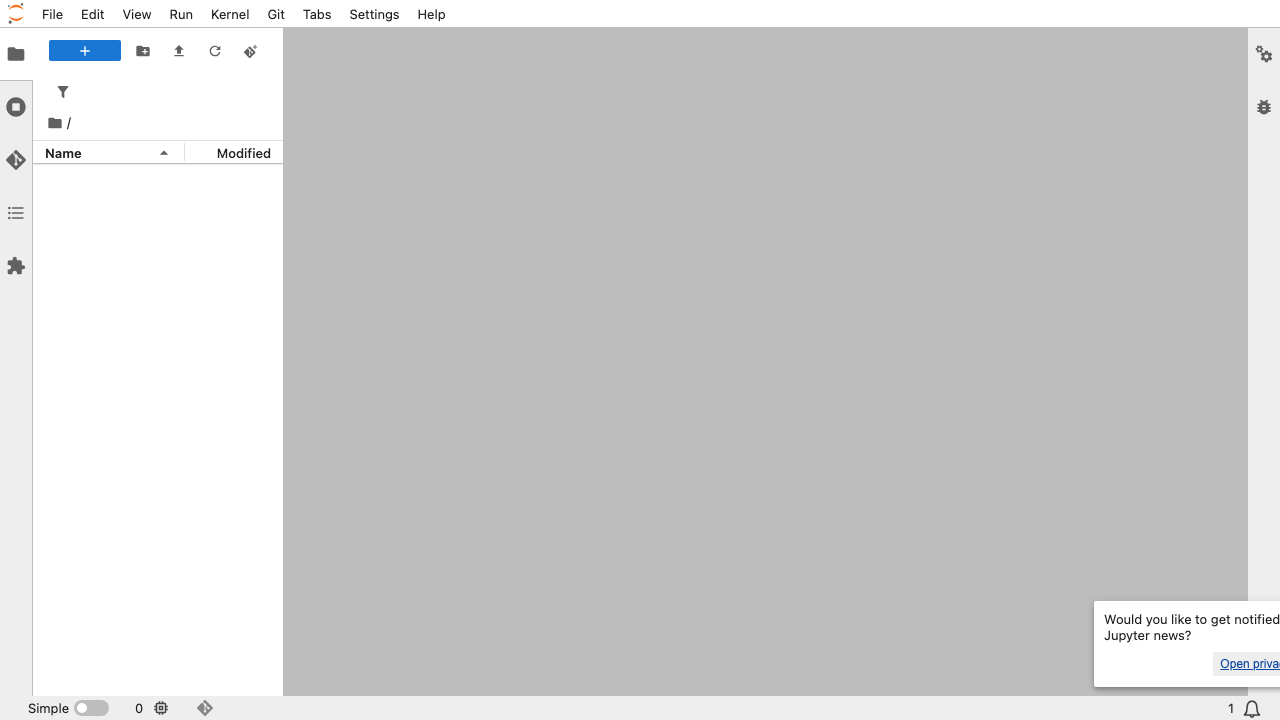

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{jupyterlab_url}?token={jupyter_token}")
    
    # Wait for JupyterLab to load
    await expect(page.locator('#jp-main-dock-panel')).to_be_visible(timeout=transition_timeout)

    # Wait for file browser to be visible
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)


await run_pw(_step_wait_for_loading)

## Remove existing test notebook if it exists

Start epoch: 1769145898.3406641 seconds
No existing test notebook to remove


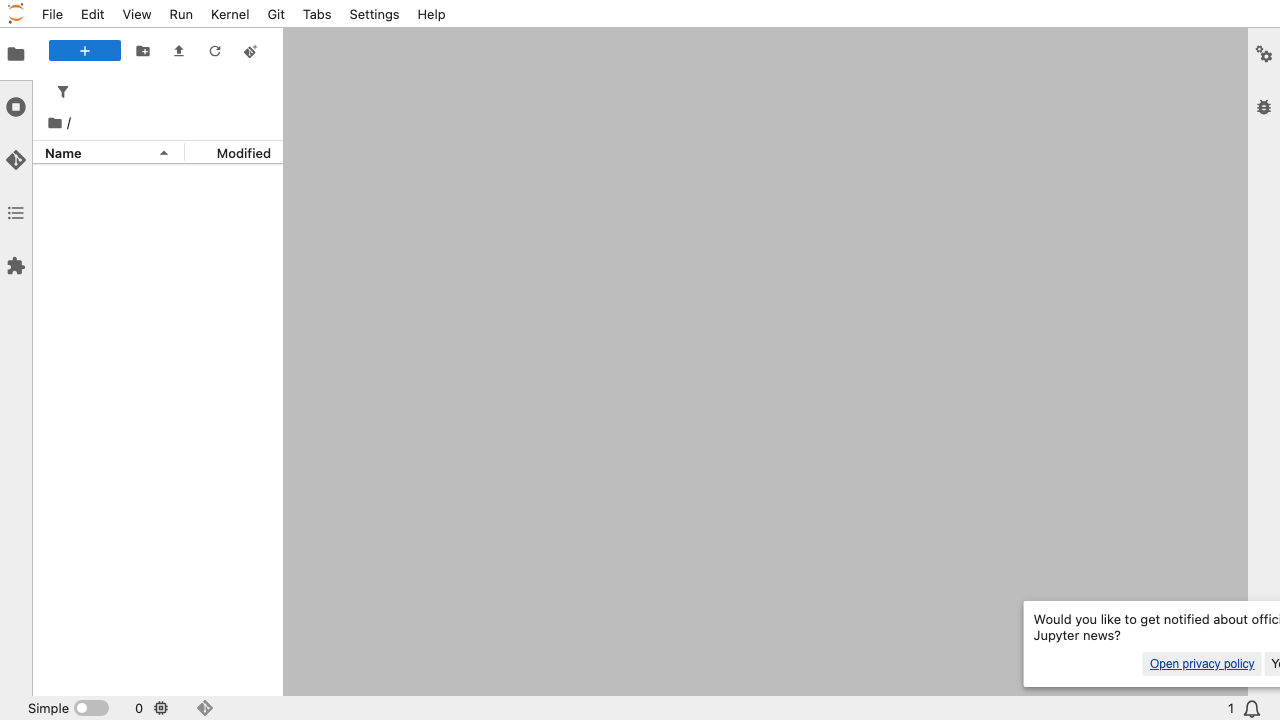

In [6]:
test_filename = "TestBasicLabNotebook.ipynb"
async def _step_remove_existing_notebook(page):
    deleted = await delete_file(page, test_filename, timeout=transition_timeout)
    if deleted:
        print("✓ Removed existing test notebook")
    else:
        print("No existing test notebook to remove")

await run_pw(_step_remove_existing_notebook)

## Create a new notebook for testing

Start epoch: 1769145898.441941 seconds


✓ New notebook created


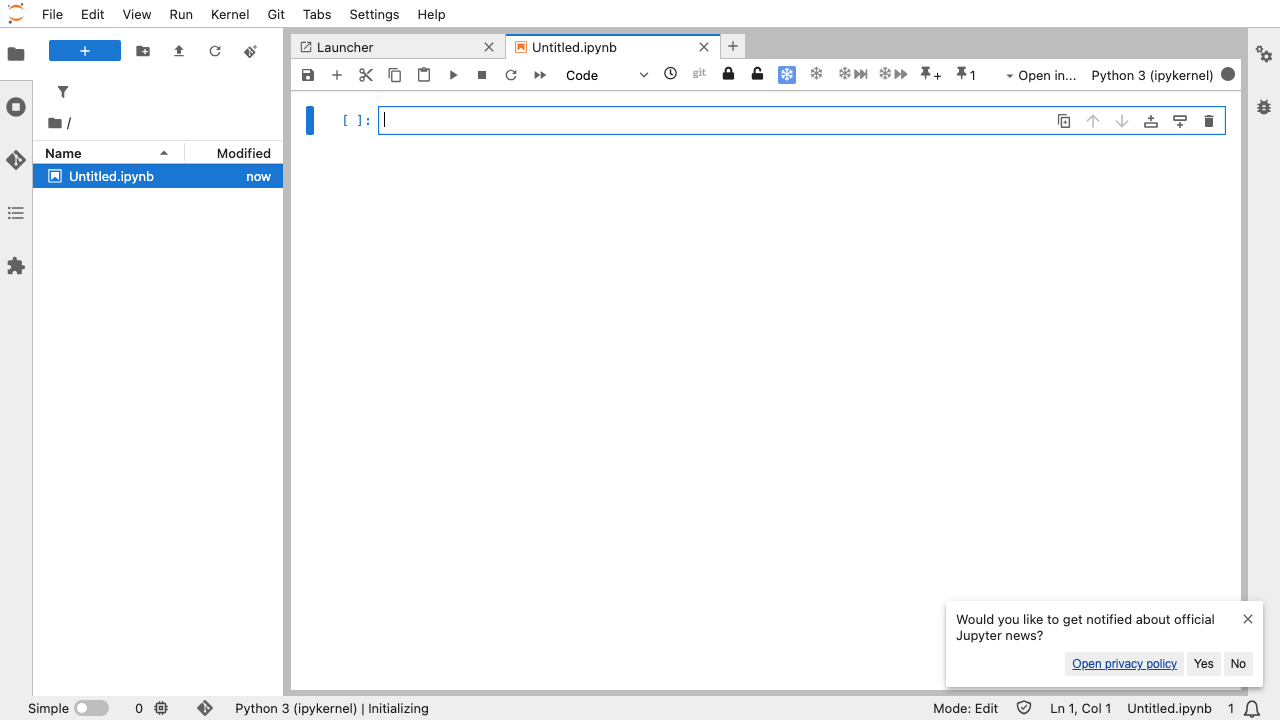

In [7]:
async def _step_create_notebook(page):
    # Create a new notebook using the jupyterlab helper
    # In JupyterLab, notebook opens in the same page
    await create_new_notebook(page, timeout=transition_timeout)
    print(f"✓ New notebook created")

await run_pw(_step_create_notebook)

## Rename and save the notebook

Start epoch: 1769145899.626248 seconds


✓ Notebook renamed and saved: TestBasicLabNotebook.ipynb


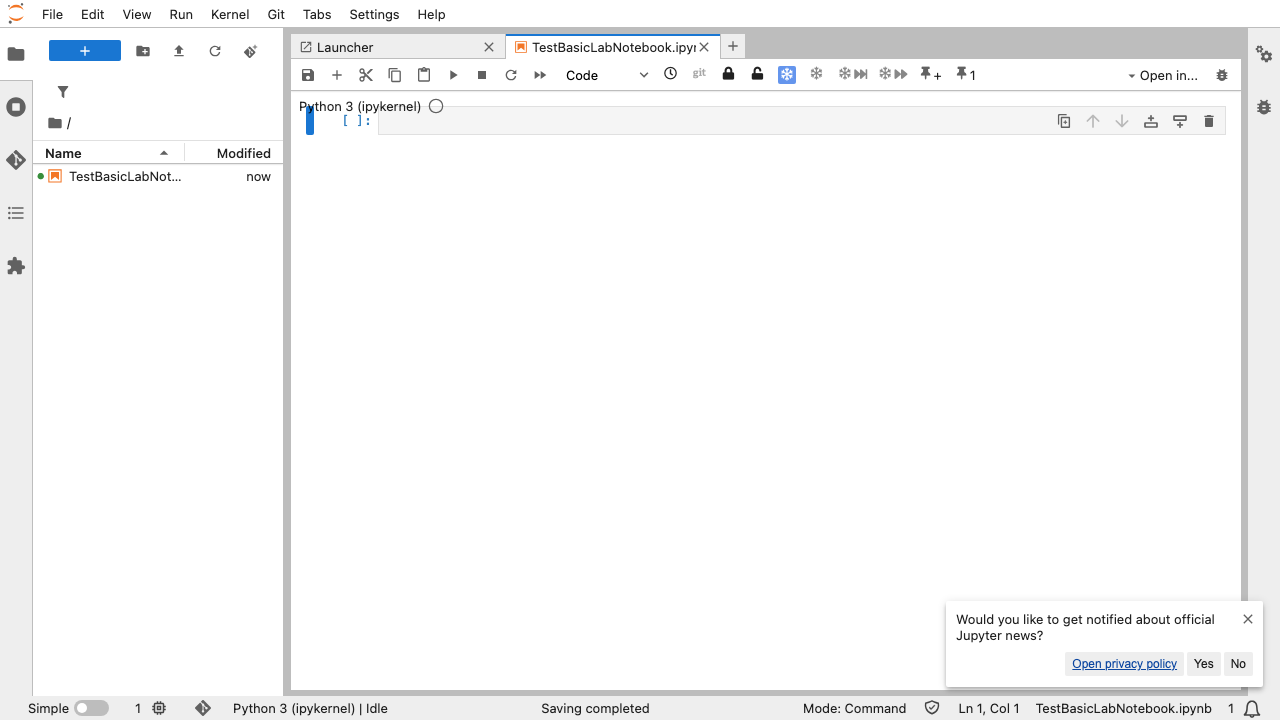

In [8]:
async def _step_rename_and_save(page):
    # Rename the notebook
    await rename_notebook(page, test_filename, timeout=transition_timeout)
    
    # Save the notebook
    await save_notebook(page)
    
    print(f"✓ Notebook renamed and saved: {test_filename}")

await run_pw(_step_rename_and_save)

## Create sections with markdown headings and code cells

Start epoch: 1769145901.545471 seconds


✓ Test structure created with 2 sections
  - Section 1: 3 code cells
  - Section 2: 3 code cells


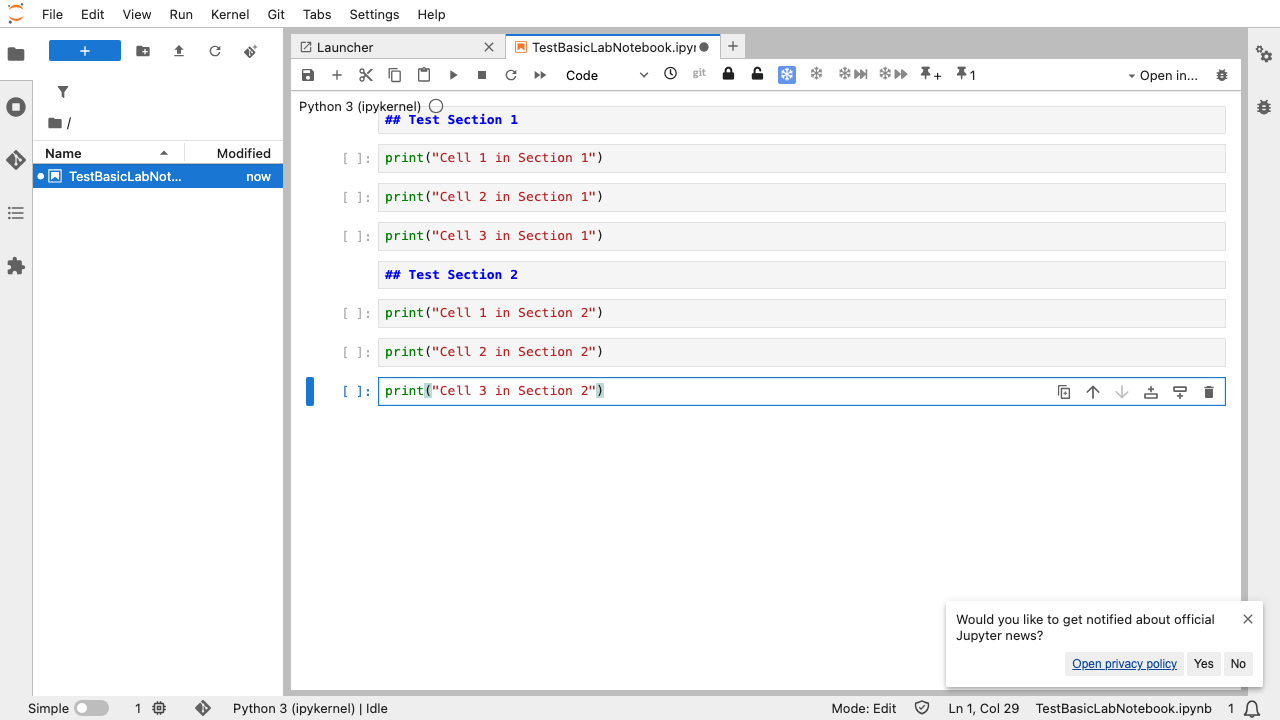

In [9]:
async def _step_create_test_structure(page):
    # Replace the first cell with a markdown heading
    await set_cell(page, 0, "markdown", "## Test Section 1", timeout=transition_timeout)
    
    # Add code cells under Section 1
    await add_cell(page, "code", 'print("Cell 1 in Section 1")', timeout=transition_timeout)
    await add_cell(page, "code", 'print("Cell 2 in Section 1")', timeout=transition_timeout)
    await add_cell(page, "code", 'print("Cell 3 in Section 1")', timeout=transition_timeout)
    
    # Add another section
    await add_cell(page, "markdown", "## Test Section 2", timeout=transition_timeout)
    await add_cell(page, "code", 'print("Cell 1 in Section 2")', timeout=transition_timeout)
    await add_cell(page, "code", 'print("Cell 2 in Section 2")', timeout=transition_timeout)
    await add_cell(page, "code", 'print("Cell 3 in Section 2")', timeout=transition_timeout)
    
    print("✓ Test structure created with 2 sections")
    print("  - Section 1: 3 code cells")
    print("  - Section 2: 3 code cells")

await run_pw(_step_create_test_structure)

## Collapse Section 1 and verify section summary widget appears

Start epoch: 1769145925.308321 seconds


✓ Section 1 collapsed and section summary widget appeared
✓ 3 unexecuted (gray) bricks displayed


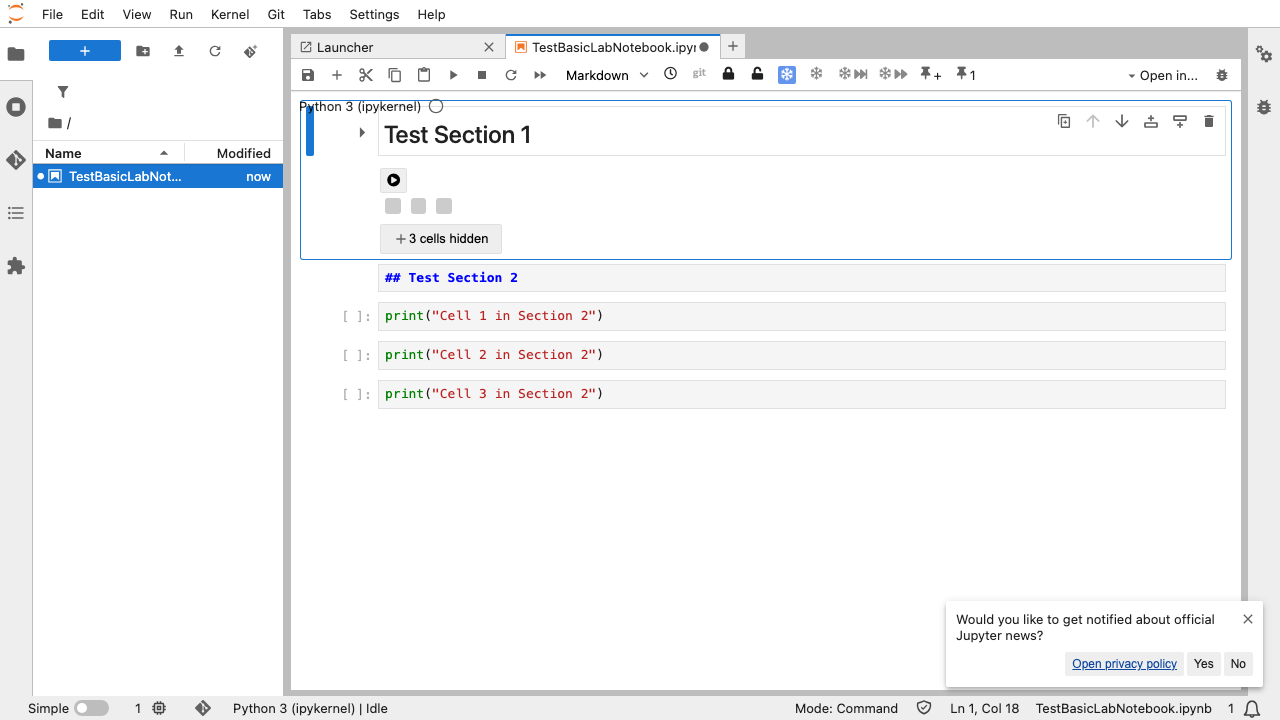

In [10]:
async def _step_collapse_section(page):
    # Execute the markdown cell to render it
    await run_cell(page, 0, wait_for_output=False, timeout=transition_timeout)
    await page.wait_for_timeout(1000)

    # Get the first markdown cell (Section 1 heading)
    heading_cell = await get_cell(page, 0, timeout=transition_timeout)
    
    # Find and click the collapse button
    # The collapsible headings extension adds a button to collapse sections
    # Look for the jp-collapseHeadingButton class
    prompt = heading_cell.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button = heading_cell.locator('.jp-collapseHeadingButton')
    await expect(collapse_button).to_be_visible(timeout=transition_timeout)
    await collapse_button.click()
    
    # Wait a bit for the collapse animation
    await page.wait_for_timeout(1000)
    
    # Verify that the section summary widget appears
    section_summary = heading_cell.locator('.lc-SectionSummaryWidget')
    await expect(section_summary).to_be_visible(timeout=transition_timeout)
    
    # Verify the run button is visible
    run_button = section_summary.locator('button.run-through-button')
    await expect(run_button).to_be_visible(timeout=transition_timeout)
    
    # Verify execution result bricks container is visible
    bricks_container = section_summary.locator('.run-through-section-cells')
    await expect(bricks_container).to_be_visible(timeout=transition_timeout)
    
    # Verify there are 3 unexecuted (gray) bricks
    # Unexecuted bricks have class 'run-through-code-result' but NOT 'run-through-code-result__success' or '__error'
    all_bricks = bricks_container.locator('.run-through-code-result')
    await expect(all_bricks).to_have_count(3, timeout=transition_timeout)
    
    # Verify none of them have success or error classes (they should all be gray/pending)
    success_bricks = bricks_container.locator('.run-through-code-result__success')
    error_bricks = bricks_container.locator('.run-through-code-result__error')
    await expect(success_bricks).to_have_count(0)
    await expect(error_bricks).to_have_count(0)
    
    print("✓ Section 1 collapsed and section summary widget appeared")
    print("✓ 3 unexecuted (gray) bricks displayed")

await run_pw(_step_collapse_section)

## Execute Section 1 using the run button

Start epoch: 1769145927.7565608 seconds


✓ Section 1 executed successfully - all cells show green bricks


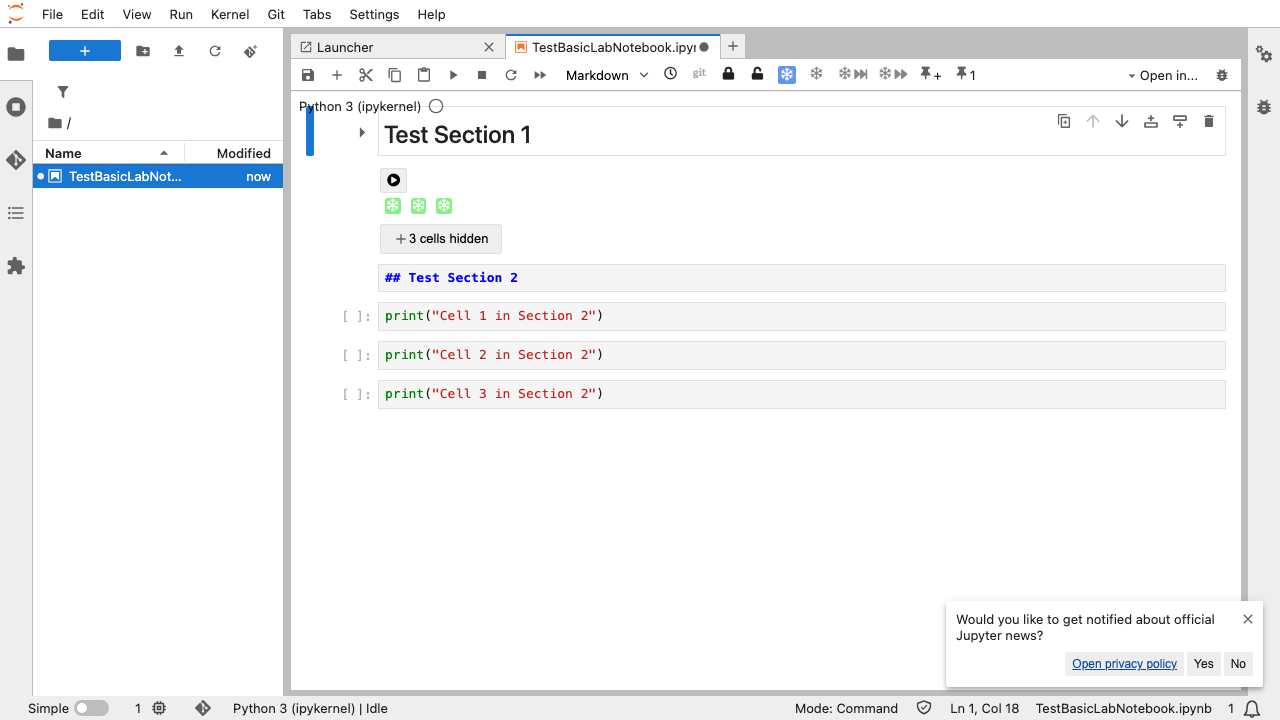

In [11]:
async def _step_execute_section(page):
    # Get the section summary widget
    heading_cell = await get_cell(page, 0, timeout=transition_timeout)
    section_summary = heading_cell.locator('.lc-SectionSummaryWidget')
    
    # Click the run button
    run_button = section_summary.locator('button.run-through-button')
    await run_button.click()
    
    # Wait a bit more to ensure all cells finish executing
    await page.wait_for_timeout(2000)
    
    # Verify that execution result bricks show success (green)
    bricks_container = section_summary.locator('.run-through-section-cells')
    success_bricks = bricks_container.locator('.run-through-code-result__success')
    
    # We should have 3 success bricks (one for each code cell in Section 1)
    await expect(success_bricks).to_have_count(3, timeout=transition_timeout)
    
    print("✓ Section 1 executed successfully - all cells show green bricks")

await run_pw(_step_execute_section)

## Expand section and verify frozen state

Start epoch: 1769145929.936459 seconds


✓ Section expanded - all executed cells show frozen state (snowflake icons)


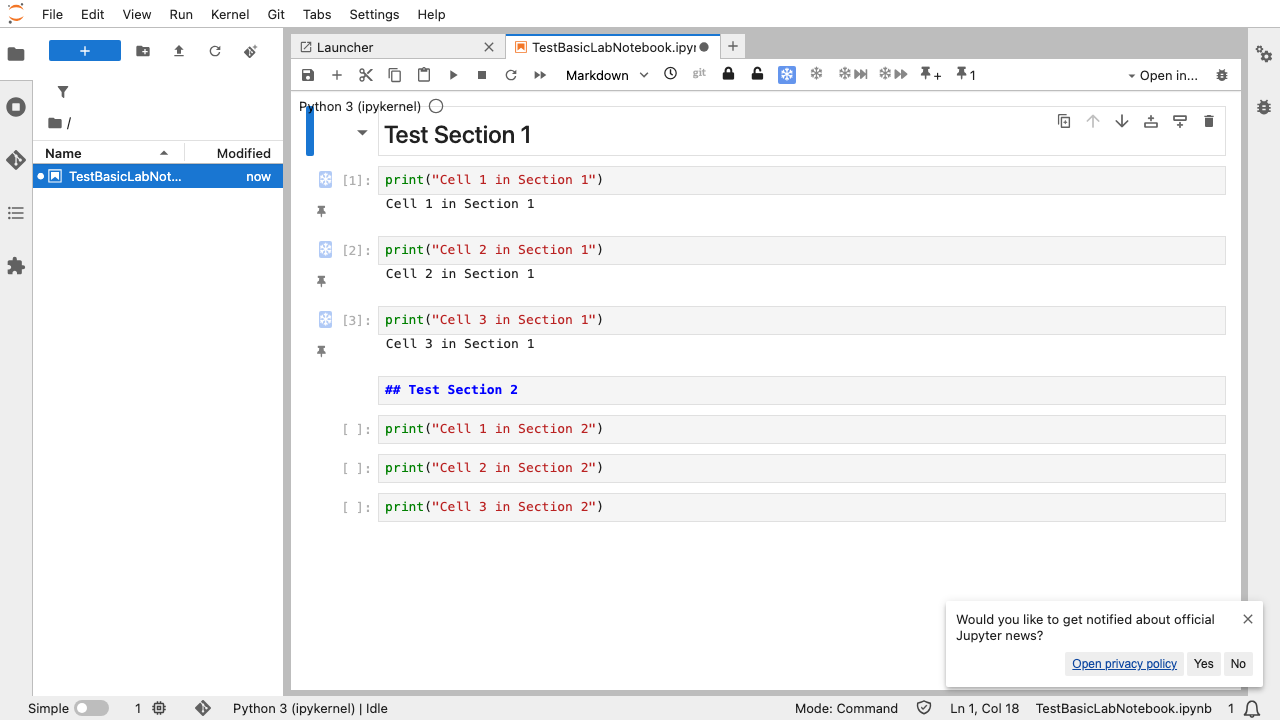

In [12]:
async def _step_verify_frozen_state(page):
    # Expand the section by clicking the collapse button again
    heading_cell = await get_cell(page, 0, timeout=transition_timeout)
    prompt = heading_cell.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button = heading_cell.locator('.jp-collapseHeadingButton')
    await collapse_button.click()
    
    # Wait for expand animation
    await page.wait_for_timeout(1000)
    
    # Verify that the code cells are now visible
    # Cells 1, 2, 3 should be code cells under the heading
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    cell_2 = await get_cell(page, 2, timeout=transition_timeout)
    cell_3 = await get_cell(page, 3, timeout=transition_timeout)
    
    # Verify frozen widgets (snowflake icons) are visible on all executed cells
    frozen_widget_1 = cell_1.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_widget_2 = cell_2.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_widget_3 = cell_3.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    
    await expect(frozen_widget_1).to_be_visible(timeout=transition_timeout)
    await expect(frozen_widget_2).to_be_visible(timeout=transition_timeout)
    await expect(frozen_widget_3).to_be_visible(timeout=transition_timeout)
    
    print("✓ Section expanded - all executed cells show frozen state (snowflake icons)")

await run_pw(_step_verify_frozen_state)

## Verify frozen cells do not re-execute

Start epoch: 1769145931.248052 seconds


Execution count before: [1]:


Execution count after: [1]:
✓ Frozen cell did not re-execute - execution count unchanged


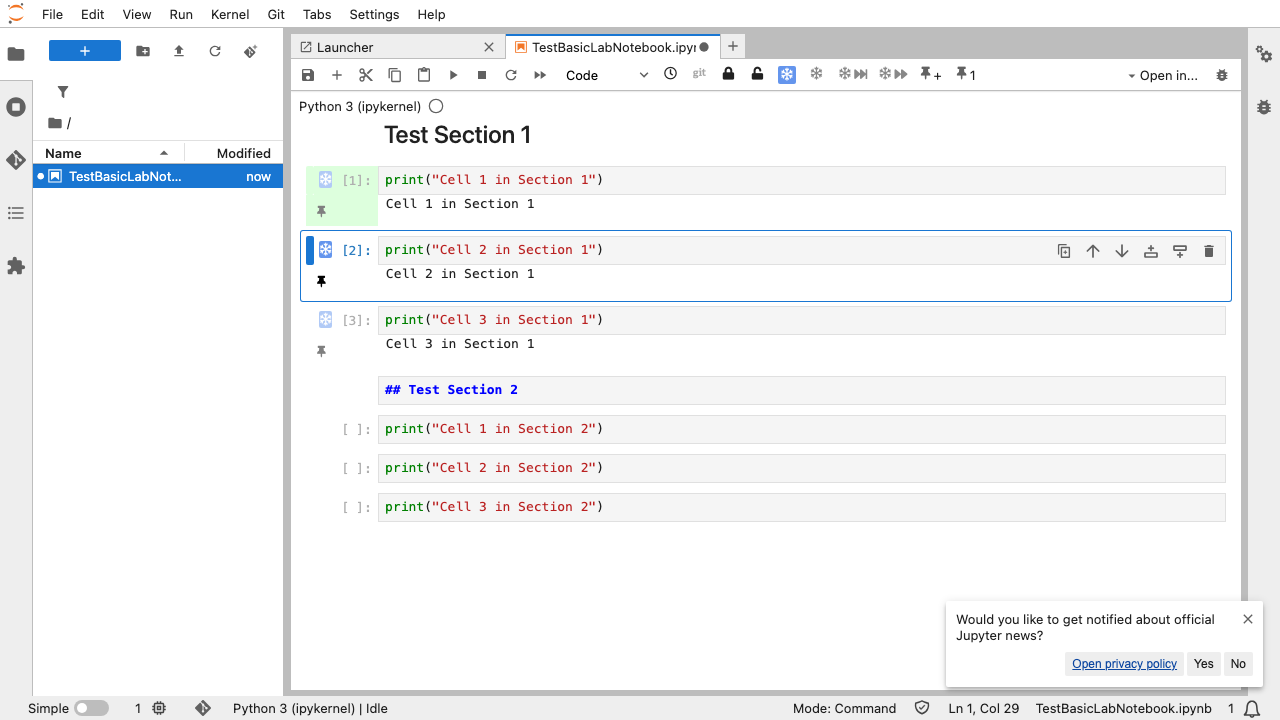

In [13]:
async def _step_verify_no_reexecution(page):
    # Select the first code cell (cell index 1)
    await select_cell(page, 1, timeout=transition_timeout)
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    
    # Get the current execution count
    prompt = cell_1.locator('.jp-InputArea-prompt')
    prompt_text_before = await prompt.text_content()
    execution_count_before = prompt_text_before.strip()
    
    print(f"Execution count before: {execution_count_before}")
    
    # Try to execute the frozen cell using run_cell (but it shouldn't execute)
    await run_cell(page, 1, wait_for_output=False, timeout=transition_timeout)
    await page.wait_for_timeout(1000)
    
    # Get the execution count again - it should not have changed
    prompt_text_after = await prompt.text_content()
    execution_count_after = prompt_text_after.strip()
    
    print(f"Execution count after: {execution_count_after}")
    
    # Verify the execution count didn't change (cell didn't re-execute)
    assert execution_count_before == execution_count_after, \
        f"Frozen cell was re-executed! Before: {execution_count_before}, After: {execution_count_after}"
    
    print("✓ Frozen cell did not re-execute - execution count unchanged")

await run_pw(_step_verify_no_reexecution)

## Unfreeze a cell and verify it can re-execute

Start epoch: 1769145932.590643 seconds
Execution count before unfreeze: [1]:


✓ Cell unfrozen - snowflake icon disappeared
Execution count after re-execution: [4]:
✓ Unfrozen cell successfully re-executed - execution count increased


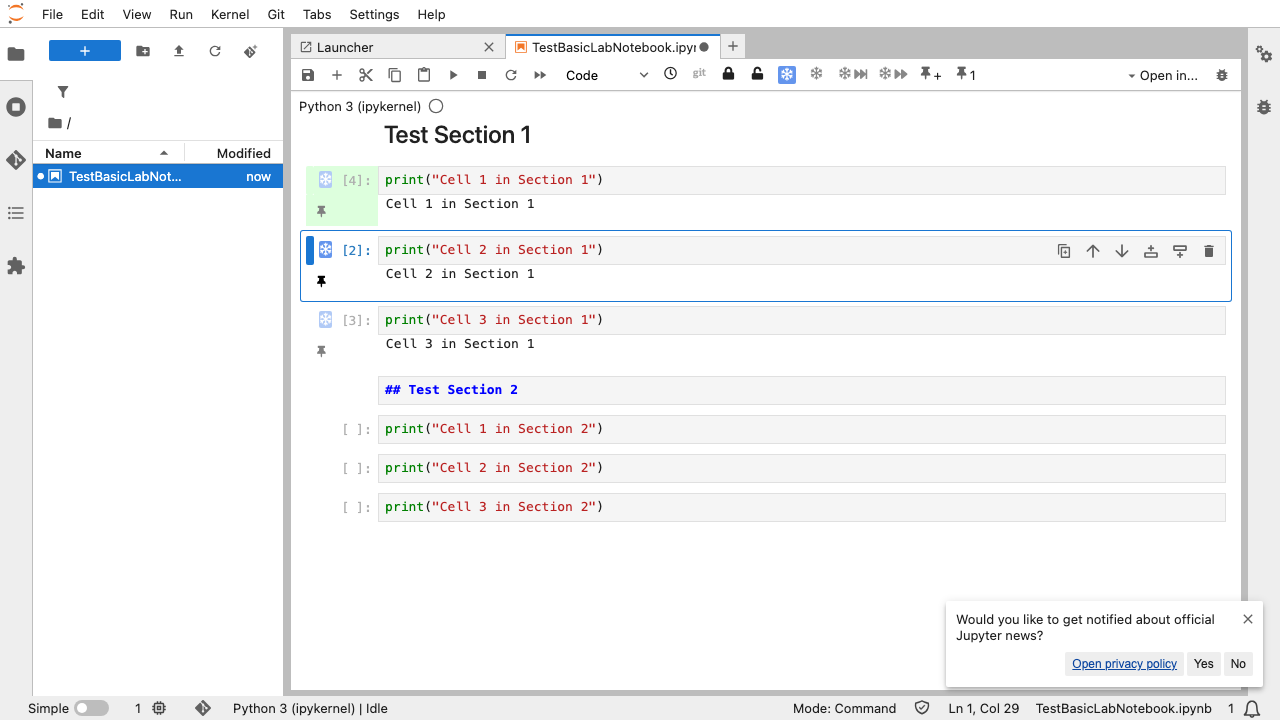

In [14]:
async def _step_unfreeze_and_reexecute(page):
    # Cell 1 should still be selected from previous step
    await select_cell(page, 1, timeout=transition_timeout)
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    
    # Get the current execution count
    prompt = cell_1.locator('.jp-InputArea-prompt')
    prompt_text_before = await prompt.text_content()
    execution_count_before = prompt_text_before.strip()
    
    print(f"Execution count before unfreeze: {execution_count_before}")
    
    # Click the unfreeze button in the toolbar
    panel = await get_active_panel(page, timeout=transition_timeout)
    unfreeze_button = panel.locator('.run-through-toolbar-button__unfreeze')
    await expect(unfreeze_button).to_be_visible(timeout=transition_timeout)
    await unfreeze_button.click()
    
    # Wait a bit for the state change
    await page.wait_for_timeout(500)
    
    # Verify the frozen widget is no longer visible
    frozen_widget = cell_1.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    await expect(frozen_widget).not_to_be_visible()
    
    print("✓ Cell unfrozen - snowflake icon disappeared")
    
    # Now execute the cell again using run_cell
    await run_cell(page, 1, wait_for_output=True, timeout=transition_timeout)
    
    # Get the execution count again - it should have increased
    prompt_text_after = await prompt.text_content()
    execution_count_after = prompt_text_after.strip()
    
    print(f"Execution count after re-execution: {execution_count_after}")
    
    # Verify the execution count changed (cell was re-executed)
    assert execution_count_before != execution_count_after, \
        f"Unfrozen cell did not re-execute! Before: {execution_count_before}, After: {execution_count_after}"
    
    print("✓ Unfrozen cell successfully re-executed - execution count increased")

await run_pw(_step_unfreeze_and_reexecute)

## Test execution result bricks with error (pink brick)

Start epoch: 1769145933.4973319 seconds


✓ Error cell executed


✓ Error brick (pink) displayed correctly for failed cell
✓ Mixed state bricks verified: 1 pink (error) + 2 gray (unexecuted)


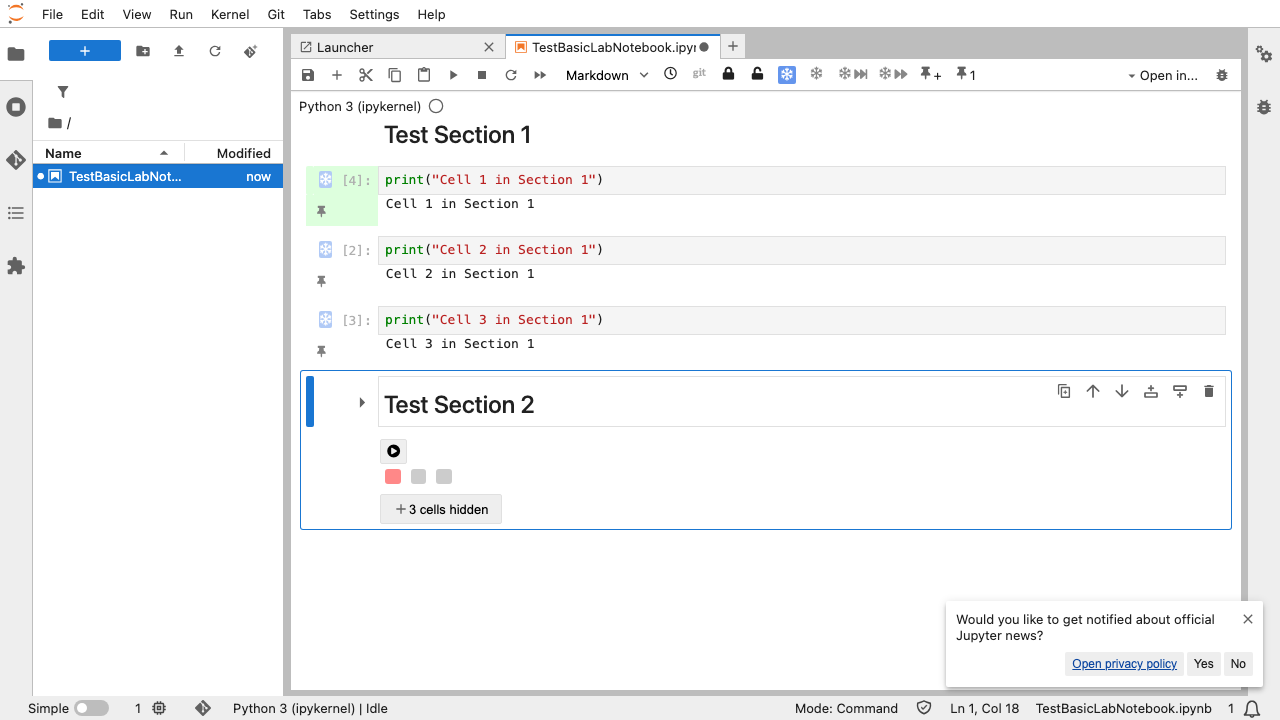

In [15]:
async def _step_test_error_brick(page):
    # Modify the first cell in Section 2 to cause an error
    # Cell indices: 0:heading1, 1-3:section1 cells, 4:heading2, 5-7:section2 cells
    error_cell_index = 5
    
    # Set the cell content to raise an error
    await set_cell(page, error_cell_index, "code", 'raise ValueError("Test error for pink brick")', timeout=transition_timeout)
    
    # Execute the error cell
    await run_cell(page, error_cell_index, wait_for_output=True, timeout=transition_timeout)
    
    # Wait a bit for the error to be registered
    await page.wait_for_timeout(1000)
    
    print("✓ Error cell executed")
    
    # Execute the markdown cell to render it if not already rendered
    await run_cell(page, 4, wait_for_output=False, timeout=transition_timeout)
    await page.wait_for_timeout(500)

    # Now collapse Section 2 to see the error brick
    heading_cell_2 = await get_cell(page, 4, timeout=transition_timeout)
    
    # Find and click the collapse button for Section 2
    prompt = heading_cell_2.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button_2 = heading_cell_2.locator('.jp-collapseHeadingButton')
    await expect(collapse_button_2).to_be_visible(timeout=transition_timeout)
    await collapse_button_2.click()
    
    # Wait for collapse animation
    await page.wait_for_timeout(1000)
    
    # Get the section summary widget for Section 2
    section_summary_2 = heading_cell_2.locator('.lc-SectionSummaryWidget')
    await expect(section_summary_2).to_be_visible(timeout=transition_timeout)
    
    # Verify execution result bricks in Section 2
    bricks_container_2 = section_summary_2.locator('.run-through-section-cells')
    
    # Should have 3 bricks total (1 error pink + 2 unexecuted gray)
    all_bricks = bricks_container_2.locator('.run-through-code-result')
    await expect(all_bricks).to_have_count(3, timeout=transition_timeout)
    
    # Should have 1 error brick (pink)
    error_bricks = bricks_container_2.locator('.run-through-code-result__error')
    await expect(error_bricks).to_have_count(1, timeout=transition_timeout)
    
    # Should have 0 success bricks (the other cells haven't been executed)
    success_bricks = bricks_container_2.locator('.run-through-code-result__success')
    await expect(success_bricks).to_have_count(0)
    
    print("✓ Error brick (pink) displayed correctly for failed cell")
    print("✓ Mixed state bricks verified: 1 pink (error) + 2 gray (unexecuted)")

await run_pw(_step_test_error_brick)

## Verify frozen bricks show snowflake icon in collapsed view

Start epoch: 1769145942.254266 seconds


✓ All 3 frozen success bricks show snowflake icon in collapsed view


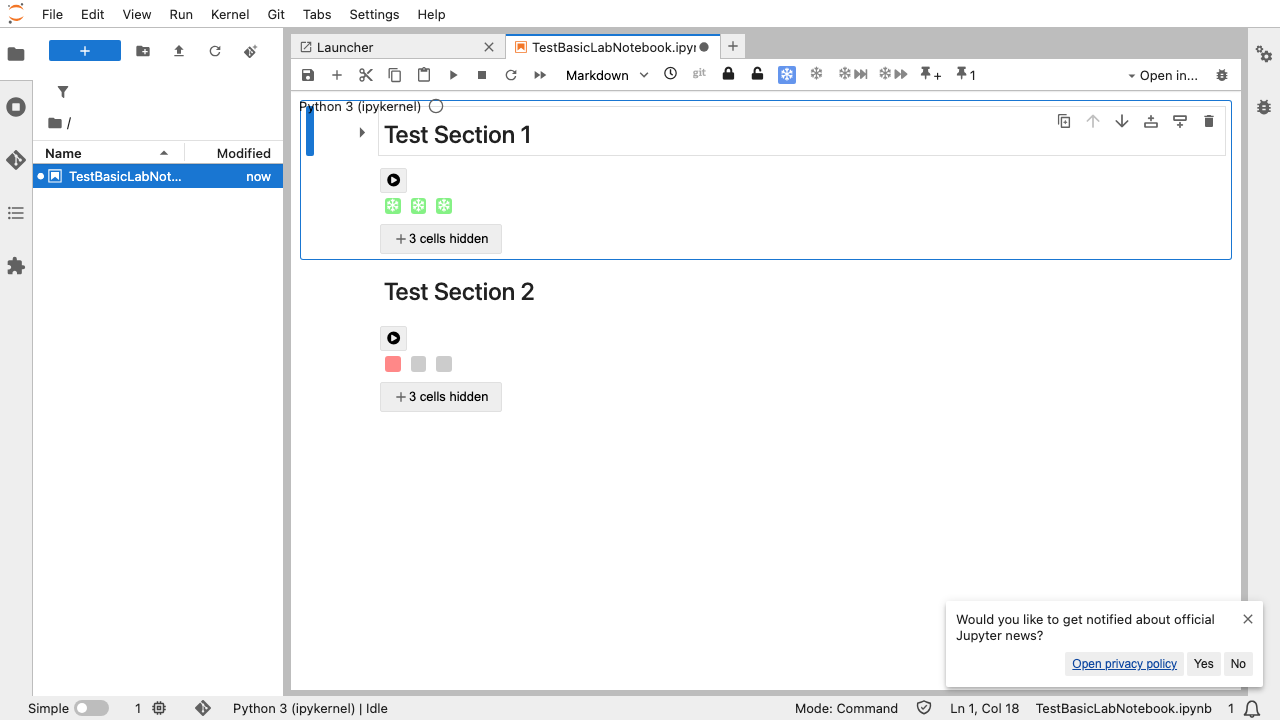

In [16]:
async def _step_verify_frozen_bricks(page):
    # Go back to Section 1 which has frozen cells and is currently expanded
    # Collapse it to see the bricks
    heading_cell_1 = await get_cell(page, 0, timeout=transition_timeout)
    
    # Collapse the section
    prompt = heading_cell_1.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button = heading_cell_1.locator('.jp-collapseHeadingButton')
    await collapse_button.click()
    await page.wait_for_timeout(1000)
    
    # Get the section summary widget
    section_summary_1 = heading_cell_1.locator('.lc-SectionSummaryWidget')
    await expect(section_summary_1).to_be_visible(timeout=transition_timeout)
    
    bricks_container_1 = section_summary_1.locator('.run-through-section-cells')
    
    # Verify that the success bricks (green) also have the snowflake icon class
    # Frozen bricks have both 'run-through-code-result__success' and 'fa-snowflake' classes
    frozen_success_bricks = bricks_container_1.locator('.run-through-code-result__success.fa-snowflake')
    
    # All 3 cells in Section 1 should be frozen success bricks
    await expect(frozen_success_bricks).to_have_count(3, timeout=transition_timeout)
    
    print("✓ All 3 frozen success bricks show snowflake icon in collapsed view")

await run_pw(_step_verify_frozen_bricks)

## Test Lock/Unlock (read-only) toolbar button

Start epoch: 1769145943.593888 seconds


✓ Cell unfrozen for lock/unlock testing
Original content: print("Cell 1 in Section 1")


✓ Cell locked (read-only state set)


✓ Locked cell content remained unchanged (read-only prevented editing)


✓ Cell unlocked and verified editable by successfully changing content


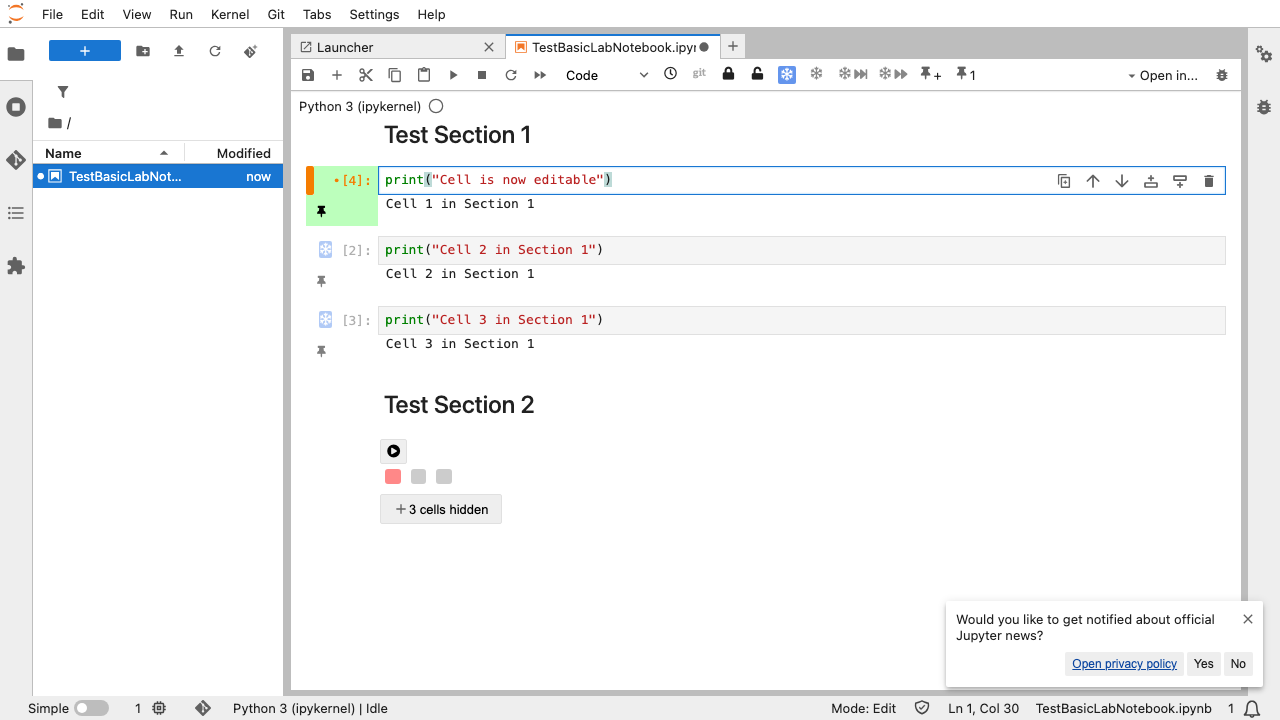

In [17]:
async def _step_test_lock_unlock(page):
    # Expand Section 1 to access individual cells
    heading_cell_1 = await get_cell(page, 0, timeout=transition_timeout)
    prompt = heading_cell_1.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button = heading_cell_1.locator('.jp-collapseHeadingButton')
    await collapse_button.click()
    await page.wait_for_timeout(1000)
    
    # Select cell 1 (index 1)
    await select_cell(page, 1, timeout=transition_timeout)
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    
    # First, unfreeze the cell so we can test lock/unlock functionality
    panel = await get_active_panel(page, timeout=transition_timeout)
    unfreeze_button = panel.locator('.run-through-toolbar-button__unfreeze')
    await expect(unfreeze_button).to_be_visible(timeout=transition_timeout)
    await unfreeze_button.click()
    await page.wait_for_timeout(500)
    
    print("✓ Cell unfrozen for lock/unlock testing")
    
    # Get the original content before locking
    original_content = await cell_1.locator('.jp-Editor').text_content()
    print(f"Original content: {original_content.strip()}")
    
    # Click the lock button (make read-only)
    lock_button = panel.locator('.run-through-toolbar-button[title="make selected cells read-only"]')
    await expect(lock_button).to_be_visible(timeout=transition_timeout)
    await lock_button.click()
    
    # Wait for state change
    await page.wait_for_timeout(500)
    
    print("✓ Cell locked (read-only state set)")
    
    # Try to change the cell content - this should not work because it's locked
    await set_cell(page, 1, "code", 'print("THIS SHOULD NOT APPEAR - CELL IS LOCKED")', timeout=transition_timeout)
    
    # Wait a bit and check if content changed
    await page.wait_for_timeout(500)
    content_after_lock_attempt = await cell_1.locator('.jp-Editor').text_content()
    
    # Verify content did NOT change (cell is read-only)
    assert original_content == content_after_lock_attempt, \
        f"Cell content should not change when locked! Original: {original_content}, After: {content_after_lock_attempt}"
    
    print("✓ Locked cell content remained unchanged (read-only prevented editing)")
    
    # Now unlock the cell
    unlock_button = panel.locator('.run-through-toolbar-button[title="make selected cells editable"]')
    await expect(unlock_button).to_be_visible(timeout=transition_timeout)
    await unlock_button.click()
    
    # Wait for state change
    await page.wait_for_timeout(500)
    
    # Verify the cell is editable by setting new content
    await set_cell(page, 1, "code", 'print("Cell is now editable")', timeout=transition_timeout)
    
    # Verify the content changed
    updated_content = await cell_1.locator('.jp-Editor').text_content()
    assert "Cell is now editable" in updated_content, "Cell should be editable after unlock"
    
    print("✓ Cell unlocked and verified editable by successfully changing content")

await run_pw(_step_test_lock_unlock)

## Test 'Unfreeze below in section' toolbar button

Start epoch: 1769145956.5969121 seconds


✓ All 3 cells in Section 1 are frozen


✓ Cell 1 remains frozen (above selected cell)
✓ Cells 2 and 3 unfrozen (selected cell and below)
✓ Cells in Section 2 remain frozen (different section)
✓ 'Unfreeze below in section' button works correctly


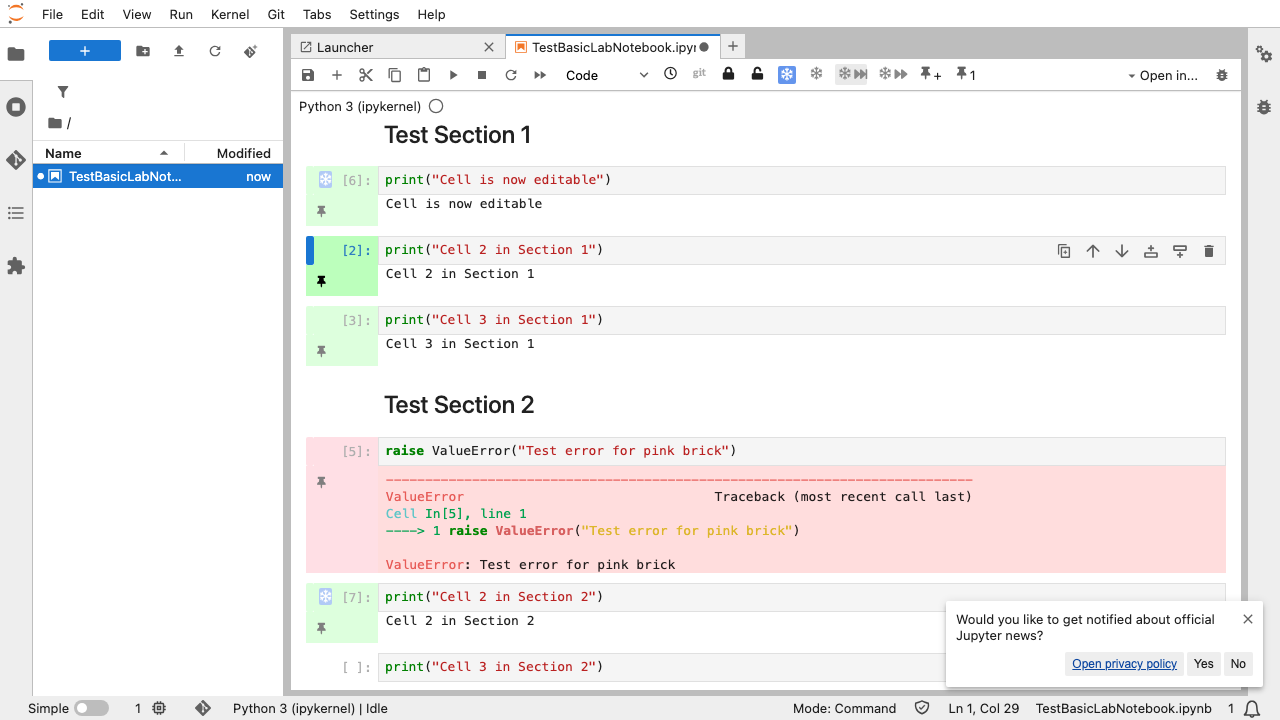

In [18]:
async def _step_test_unfreeze_below_section(page):
    # First, make sure all cells in Section 1 are frozen by re-executing them
    # Cell 1 was unfrozen in the previous lock/unlock test, so we need to re-freeze all cells
    await run_cell(page, 1, wait_for_output=True, timeout=transition_timeout)
    await run_cell(page, 2, wait_for_output=True, timeout=transition_timeout)
    await run_cell(page, 3, wait_for_output=True, timeout=transition_timeout)
    
    # Expand Section 2 to execute cells
    heading_cell_2 = await get_cell(page, 4, timeout=transition_timeout)
    prompt = heading_cell_2.locator('.jp-InputArea-prompt')
    await prompt.hover()
    collapse_button_2 = heading_cell_2.locator('.jp-collapseHeadingButton')
    await collapse_button_2.click()
    await page.wait_for_timeout(1000)
    
    # Execute cell 6 in Section 2
    await run_cell(page, 6, wait_for_output=True, timeout=transition_timeout)
    
    await page.wait_for_timeout(1000)
    
    # Verify all 3 cells in Section 1 are frozen
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    cell_2 = await get_cell(page, 2, timeout=transition_timeout)
    cell_3 = await get_cell(page, 3, timeout=transition_timeout)
    
    frozen_1 = cell_1.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_2 = cell_2.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_3 = cell_3.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    
    await expect(frozen_1).to_be_visible(timeout=transition_timeout)
    await expect(frozen_2).to_be_visible(timeout=transition_timeout)
    await expect(frozen_3).to_be_visible(timeout=transition_timeout)
    
    print("✓ All 3 cells in Section 1 are frozen")
    
    # Select cell 2 (index 2)
    # "Unfreeze below in section" unfreezes the selected cell and all cells below it in the section
    await select_cell(page, 2, timeout=transition_timeout)
    
    # Click the "Unfreeze below in section" button
    panel = await get_active_panel(page, timeout=transition_timeout)
    unfreeze_section_button = panel.locator('.run-through-toolbar-button__unfreeze-section')
    await expect(unfreeze_section_button).to_be_visible(timeout=transition_timeout)
    await unfreeze_section_button.click()
    
    # Wait for state change
    await page.wait_for_timeout(1000)
    
    # Verify: Cell 1 should remain frozen (it's above the selected cell)
    await expect(frozen_1).to_be_visible()
    print("✓ Cell 1 remains frozen (above selected cell)")
    
    # Verify: Cells 2 and 3 should be unfrozen (cell 2 is selected, cell 3 is below it)
    await expect(frozen_2).not_to_be_visible()
    await expect(frozen_3).not_to_be_visible()
    print("✓ Cells 2 and 3 unfrozen (selected cell and below)")
    
    # Verify that cell 6 in Section 2 remains frozen (different section)
    cell_6 = await get_cell(page, 6, timeout=transition_timeout)
    frozen_6 = cell_6.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    await expect(frozen_6).to_be_visible()
    
    print("✓ Cells in Section 2 remain frozen (different section)")
    print("✓ 'Unfreeze below in section' button works correctly")

await run_pw(_step_test_unfreeze_below_section)

## Test 'Unfreeze below all' toolbar button

Start epoch: 1769145960.6771982 seconds


✓ All cells are frozen (cells 1, 2, 3 in Section 1 and cell 6 in Section 2)


✓ Cell 1 remains frozen (above selected cell)
✓ Cells 2 and 3 unfrozen (selected cell and below in Section 1)
✓ Cell 6 unfrozen (below in Section 2)
✓ 'Unfreeze below all' button works correctly - unfreezes cells across all sections


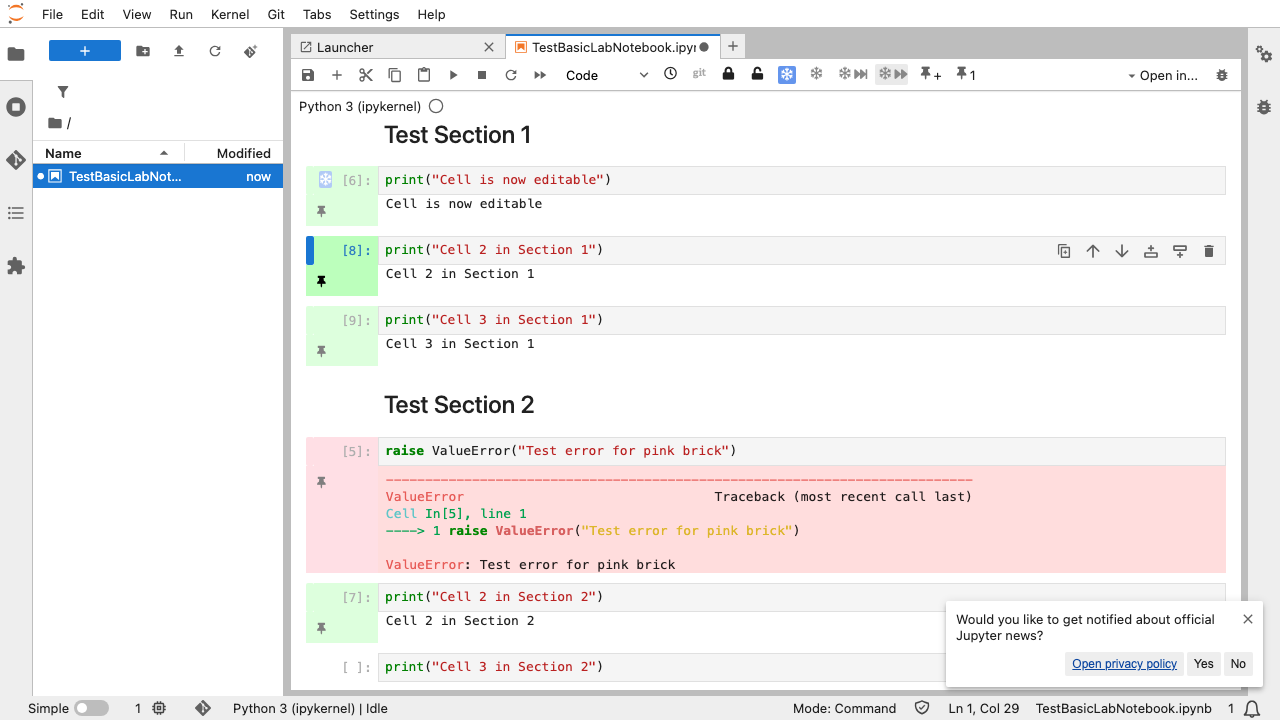

In [19]:
async def _step_test_unfreeze_below_all(page):
    # First, re-freeze all cells for a clean test
    # Select cell 1 and freeze it
    await select_cell(page, 1, timeout=transition_timeout)
    panel = await get_active_panel(page, timeout=transition_timeout)
    freeze_button = panel.locator('.run-through-toolbar-button__freeze')
    await freeze_button.click()
    await page.wait_for_timeout(500)
    
    # Re-freeze cells 2 and 3 by executing them (they were unfrozen in previous test)
    await run_cell(page, 2, wait_for_output=True, timeout=transition_timeout)
    await run_cell(page, 3, wait_for_output=True, timeout=transition_timeout)
    
    await page.wait_for_timeout(1000)
    
    # Verify all cells are frozen (cells 1, 2, 3 in Section 1 and cell 6 in Section 2)
    # Cell 6 is already frozen from previous test
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    cell_2 = await get_cell(page, 2, timeout=transition_timeout)
    cell_3 = await get_cell(page, 3, timeout=transition_timeout)
    cell_6 = await get_cell(page, 6, timeout=transition_timeout)
    
    frozen_1 = cell_1.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_2 = cell_2.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_3 = cell_3.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    frozen_6 = cell_6.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    
    await expect(frozen_1).to_be_visible(timeout=transition_timeout)
    await expect(frozen_2).to_be_visible(timeout=transition_timeout)
    await expect(frozen_3).to_be_visible(timeout=transition_timeout)
    await expect(frozen_6).to_be_visible(timeout=transition_timeout)
    
    print("✓ All cells are frozen (cells 1, 2, 3 in Section 1 and cell 6 in Section 2)")
    
    # Select cell 2 (index 2)
    # "Unfreeze below all" unfreezes the selected cell and all cells below it across all sections
    await select_cell(page, 2, timeout=transition_timeout)
    
    # Click the "Unfreeze below all" button
    unfreeze_all_button = panel.locator('.run-through-toolbar-button__unfreeze-all')
    await expect(unfreeze_all_button).to_be_visible(timeout=transition_timeout)
    await unfreeze_all_button.click()
    
    # Wait for state change
    await page.wait_for_timeout(1000)
    
    # Verify: Cell 1 should remain frozen (above the selected cell)
    await expect(frozen_1).to_be_visible()
    print("✓ Cell 1 remains frozen (above selected cell)")
    
    # Verify: Cells 2 and 3 should be unfrozen (cell 2 is selected, cell 3 is below)
    await expect(frozen_2).not_to_be_visible()
    await expect(frozen_3).not_to_be_visible()
    print("✓ Cells 2 and 3 unfrozen (selected cell and below in Section 1)")
    
    # Verify: Cell 6 should also be unfrozen (below across sections - this is the key difference from "unfreeze below in section")
    await expect(frozen_6).not_to_be_visible()
    print("✓ Cell 6 unfrozen (below in Section 2)")
    
    print("✓ 'Unfreeze below all' button works correctly - unfreezes cells across all sections")

await run_pw(_step_test_unfreeze_below_all)

## Lock cell 2 and save notebook for persistence test

Start epoch: 1769145964.025888 seconds


✓ Cell 2 locked (read_only state set)


✓ Notebook saved


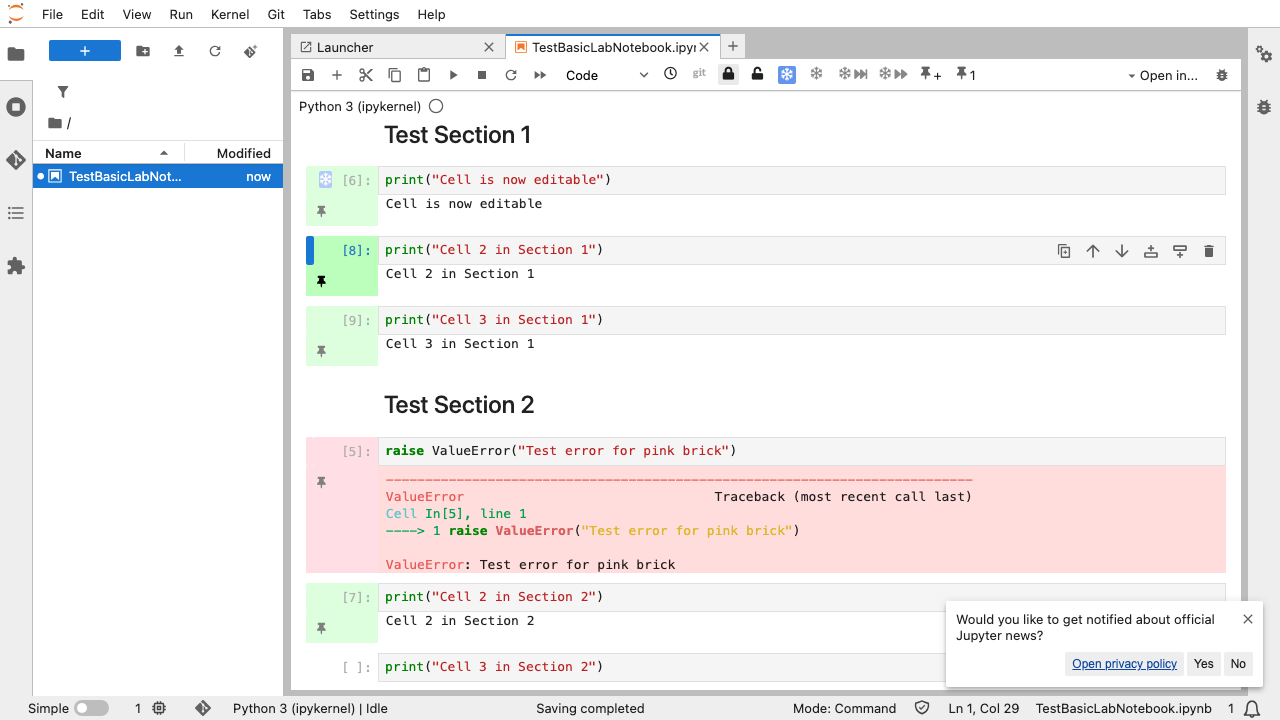

In [20]:
async def _step_lock_cell2_and_save(page):
    # Select cell 2 (index 2)
    await select_cell(page, 2, timeout=transition_timeout)
    
    # Lock the cell (make it read_only)
    panel = await get_active_panel(page, timeout=transition_timeout)
    lock_button = panel.locator('.run-through-toolbar-button[title="make selected cells read-only"]')
    await expect(lock_button).to_be_visible(timeout=transition_timeout)
    await lock_button.click()
    
    # Wait for state change
    await page.wait_for_timeout(500)
    
    print("✓ Cell 2 locked (read_only state set)")
    
    # Save the notebook
    await save_notebook(page)    
    print("✓ Notebook saved")

await run_pw(_step_lock_cell2_and_save)

## Close and reopen notebook to verify state persistence

Start epoch: 1769145965.797725 seconds


✓ Notebook tab closed


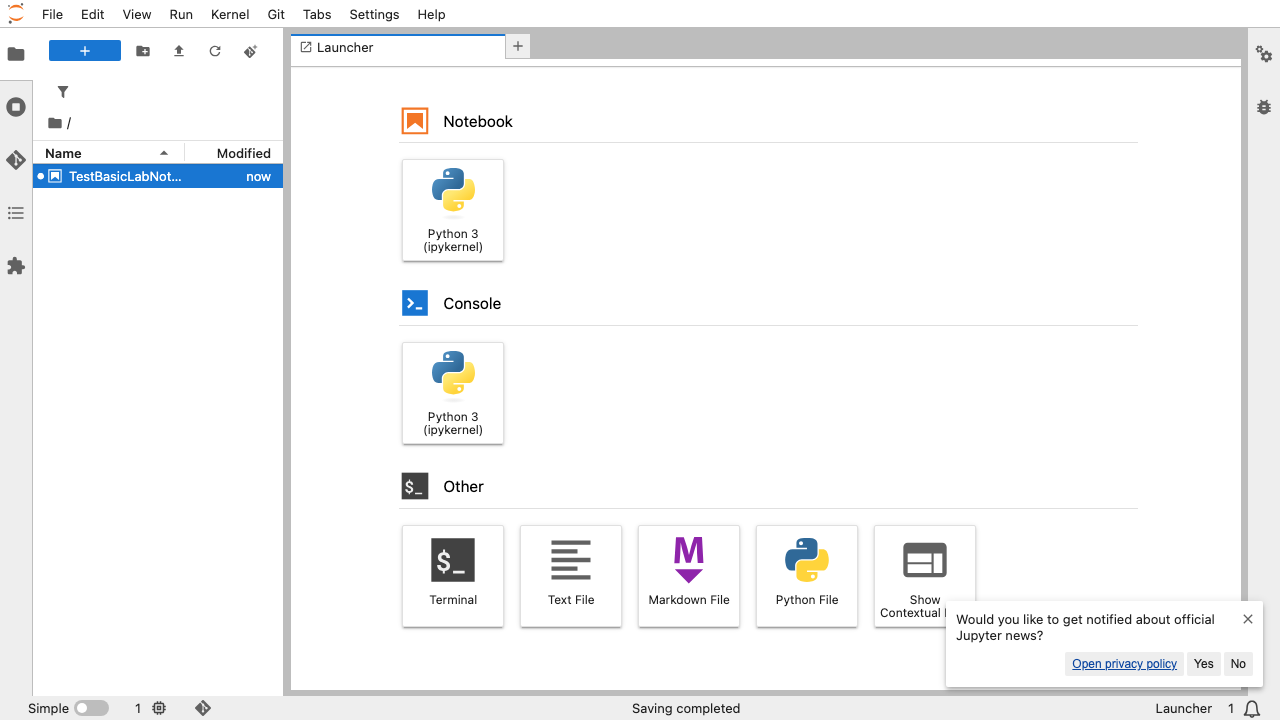

In [21]:
async def _step_close_notebook(page):
    # Find the active tab (the notebook tab)
    tab_container = page.locator('.lm-Widget.lm-TabBar.lm-DockPanel-tabBar')
    await expect(tab_container).to_be_visible(timeout=transition_timeout)
    active_tab = page.locator('.lm-TabBar-tab.lm-mod-current').filter(has_text=test_filename)
    await expect(active_tab).to_be_visible(timeout=transition_timeout)
    
    # Click the close icon on the tab
    close_icon = active_tab.locator('.lm-TabBar-tabCloseIcon')
    await expect(close_icon).to_be_visible(timeout=transition_timeout)
    await close_icon.click()
    
    # Wait for the tab to close
    await expect(active_tab).not_to_be_visible()
    
    print("✓ Notebook tab closed")

await run_pw(_step_close_notebook)

Start epoch: 1769145966.0406249 seconds


✓ Notebook reopened: TestBasicLabNotebook.ipynb


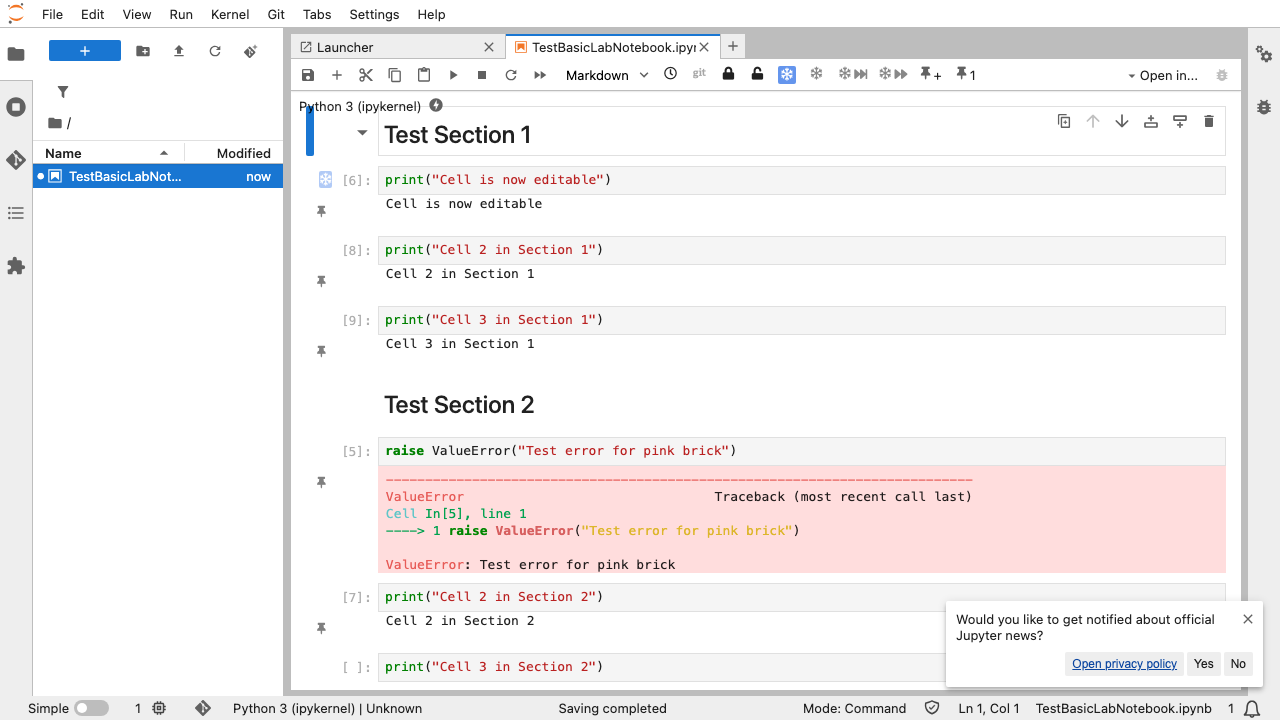

In [22]:
async def _step_reopen_notebook(page):
    # Double-click on the notebook file to open it in a new tab
    file_item = page.locator('.jp-DirListing-content li span.jp-DirListing-itemText').filter(has_text=test_filename)
    await expect(file_item).to_be_visible(timeout=transition_timeout)
    await file_item.dblclick()
    
    # Wait for notebook to be ready
    panel = await get_active_panel(page)
    await expect(panel.locator('.jp-Cell.jp-CodeCell').first).to_be_visible(timeout=transition_timeout)
    
    print(f"✓ Notebook reopened: {test_filename}")

await run_pw(_step_reopen_notebook)

## Verify frozen and read_only states are preserved after reload

Start epoch: 1769145966.4012659 seconds


✓ Cell 1 frozen state persisted (snowflake icon visible)


Cell 2 original content: print("Cell 2 in Section 1")


✓ Cell 2 read_only state persisted (cell remains uneditable)
✓ State persistence verified - frozen and read_only states preserved after save and reload


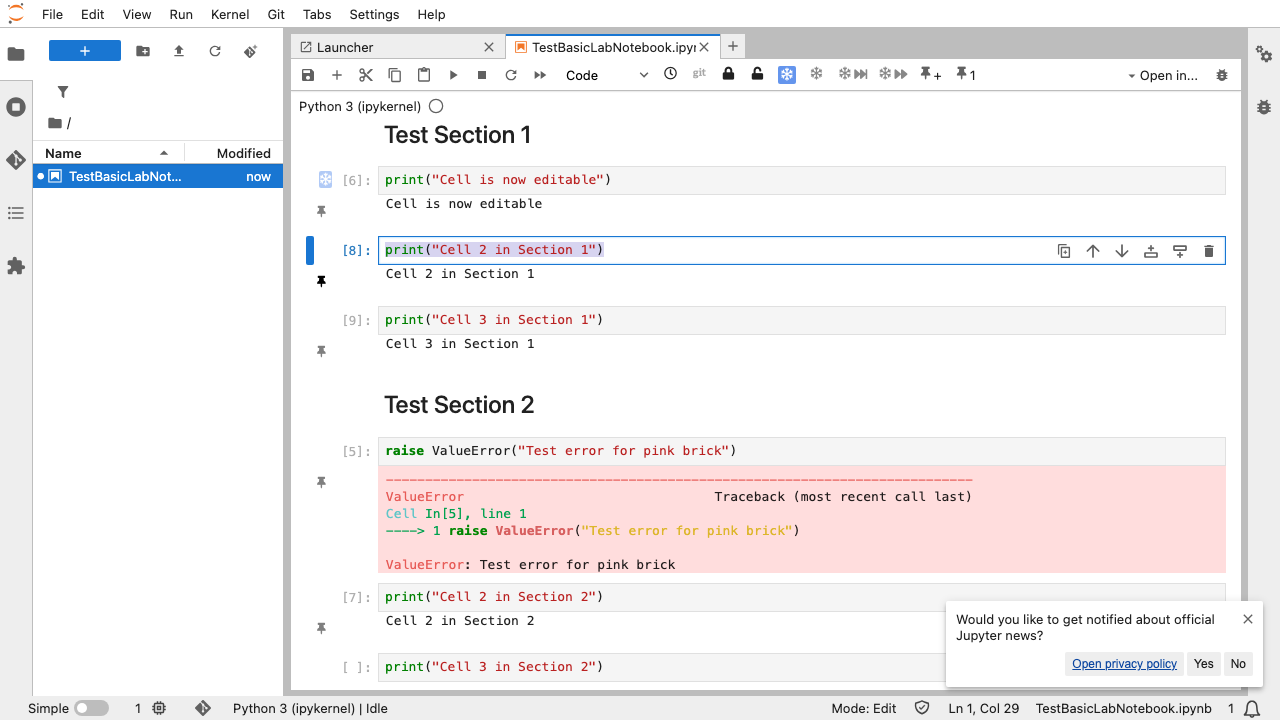

In [23]:
async def _step_verify_states_persisted(page):
    # Verify cell 1 (index 1) is still frozen
    await select_cell(page, 1, timeout=transition_timeout)
    cell_1 = await get_cell(page, 1, timeout=transition_timeout)
    
    frozen_widget_1 = cell_1.locator('.RunThrough-FrozenWidget .run-through-prompt-frozen')
    await expect(frozen_widget_1).to_be_visible(timeout=transition_timeout)
    
    print("✓ Cell 1 frozen state persisted (snowflake icon visible)")
    
    # Verify cell 2 (index 2) is still locked (read_only)
    await select_cell(page, 2, timeout=transition_timeout)
    cell_2 = await get_cell(page, 2, timeout=transition_timeout)
    
    # Get the original content
    original_content = await cell_2.locator('.jp-Editor').text_content()
    print(f"Cell 2 original content: {original_content.strip()}")
    
    # Try to change the cell content - this should not work because it's locked
    await set_cell(page, 2, "code", 'print("THIS SHOULD NOT APPEAR - CELL IS LOCKED")', timeout=transition_timeout)
    
    # Wait a bit and check if content changed
    await page.wait_for_timeout(500)
    content_after_edit_attempt = await cell_2.locator('.jp-Editor').text_content()
    
    # Verify content did NOT change (cell is still read-only)
    assert original_content == content_after_edit_attempt, \
        f"Cell content should not change when locked! Original: {original_content}, After: {content_after_edit_attempt}"
    
    print("✓ Cell 2 read_only state persisted (cell remains uneditable)")
    print("✓ State persistence verified - frozen and read_only states preserved after save and reload")

await run_pw(_step_verify_states_persisted)

## Clean up

In [ ]:
await finish_pw_context()

In [25]:
!rm -fr {work_dir}